
# Bike Rental Prediction (Daily Forecast) — Data Provisioning



## Introduction

In this notebook, I start the **data provisioning** phase for my individual AI challenge — predicting **daily bike rental demand**.  
The goal is to understand what kind of data is needed, how it is collected, and to understand the dataset itself.

This notebook will include the following parts:
1. **Data Requirements** — what kind of data I use and need  
2. **Data Collection** — how I load and store the dataset  
3. **Exploratory Research (Data Understanding)** — first observations and exploration
4. **Data Preparation** — cleaning and transforming data for modeling



## Data Provisioning
The data provisioning phase includes defining what data I use **(Data Requirements)**, how I access and organize it **(Data Collection)**, exploring and understanding the dataset **(Exploratory Research)**, and preparing it for modeling **(Data Preparation)**.



### 1) Data Requirements



#### Data Definition

The **UCI Bike Sharing Dataset**, created by **Hadi Fanaee-T**, originates from a real **bike-sharing system in Washington D.C., USA**, and was collected between **2011 and 2012**.  
It is available through the **UCI Machine Learning Repository** and includes both **hourly** and **daily** records of bike rentals, along with related **weather** and **calendar** information.  

For this project, I use the **daily dataset (`day.csv`)**, where each record represents one full day of system activity.  
This dataset is ideal because my goal is to predict the **total number of bike rentals per day**.

### Target Variable

- **`cnt`**: Represents the total number of bike rentals for a given day. This variable serves as the target in the prediction model, showing overall demand for bikes on that day.


### Data Definition (Input Variables)

- **`instant`**: It shows the order of data entries and helps to identify each observation uniquely.
- **`dteday`**: The date of the observation in the format `YYYY-MM-DD`.  It allows tracking of rentals over time and helps align patterns with specific days or months.
- **`season`**: Seasonal variation has a strong influence on bike usage, with higher rentals typically observed during warmer months.
- **`yr`**: Indicates the year of observation (0 = 2011, 1 = 2012). 
- **`mnth`**: Monthly variation is often linked to weather, holidays, and user habits.
- **`holiday`**: Bike usage may increase or decrease depending on holiday activities and reduced traffic.
- **`weekday`**: This allows analysis of weekday versus weekend behavior, where workdays may have different demand compared to leisure days.
- **`workingday`**: This feature distinguishes between normal workdays and days off, which usually have different commuting patterns.
- **`weathersit`**: Since weather directly affects outdoor activity, this variable strongly correlates with bike rental demand.
- **`temp`**: Warmer temperatures usually encourage more people to rent bikes, while extreme cold reduces usage.
- **`atemp`**: This variable captures perceived comfort and is often a more accurate reflection of how temperature affects human behavior.
- **`hum`**: High humidity can make cycling less comfortable, while moderate humidity is typically more favorable for biking.
- **`windspeed`**: Strong winds can discourage cycling, whereas mild wind has little to no effect.
- **`casual`**: The number of rentals by casual users (non-registered). 
- **`registered`**: The number of rentals by registered members. 


Each of these features helps capture the combined impact of **weather conditions, time-related patterns, and user behavior** on daily bike rental demand.}
Together, they form a structured foundation for analyzing and predicting how different circumstances influence the overall use of shared bicycles in a city environment.



#### Data Quality and Governance

- The dataset is **public and anonymized**, available through the UCI repository.  
- There are no personal or sensitive attributes.  
- Missing values are not expected, but they will be checked in the next step.  




### 2) Data Collection

The dataset file is called **`day.csv`**. I load it safely and make a local backup copy for reproducibility.  
If the file is not found in the current directory, I check common paths like `/data/` or `/mnt/data/`.


In [32]:
from pathlib import Path
import pandas as pd

# Compare temperature and "feels like" temperature
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path("data")

def find_day_csv():
    for p in [Path("day.csv"), DATA_DIR / "day.csv", Path("/mnt/data/day.csv")]:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError("Place 'day.csv' in project root or under ./data/.")

src = find_day_csv()
df_day = pd.read_csv(src)

print("Loaded file:", src)
print("Shape:", df_day.shape)
print("Columns:", list(df_day.columns))




Loaded file: C:\Users\koran\Desktop\Semester 3 AI Machine Learning and Data\Individual Challenges\First Individual Challenge\DAIA\data\day.csv
Shape: (731, 16)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']



### 3) Exploratory Research (Data Understanding)

In this part, I explore the dataset to understand its structure, quality, and relationships between features.  
The main questions are:
1. Are there any missing or incorrect values?  
2. Which features have the most impact on daily bike rentals (`cnt`)?  
3. Are there any features that are redundant or too similar (for example `temp` and `atemp`)?  


#### 1) First Look at the Data

Before analyzing relationships, I first take a look at the general structure of the dataset.  
This helps me understand what the data looks like and whether there are any obvious inconsistencies.


In [ ]:
#  first 10 rows
df_day.head(10)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


By looking at the first 10 rows, I get a general idea of how the dataset is structured.  
I can see that each row represents one day between 2011 and 2012, and the columns include weather, calendar, and rental-related data.  

In [ ]:
# data types and non-null counts
df_day.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


I see that all columns have the correct data types.  
There are no missing entries in the output, and every feature seems complete.  
This confirms that the dataset has no structural problems.

In [ ]:
# Summary - all numerical columns
df_day.describe()


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


From the summary table, I can see that all numeric columns have reasonable minimum and maximum values.  
For example, **temp**, **atemp**, **hum**, and **windspeed** are normalized between 0 and 1.  
The **cnt** column shows a wide range of rental counts, which makes sense for daily data across two years.  

In [36]:
# Check for missing values directly
df_day.isnull().sum()


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

All values are zero, meaning there are **no missing values** in this dataset.  
This matches the expectation for the UCI Bike Sharing dataset, which is already clean and well-prepared.


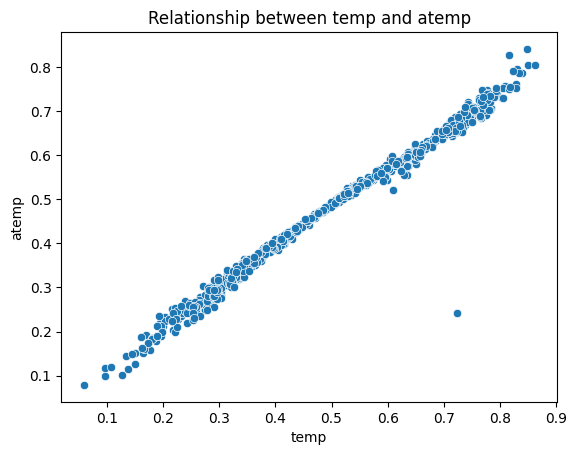

In [37]:
sns.scatterplot(data=df_day, x="temp", y="atemp")
plt.title("Relationship between temp and atemp")
plt.show()


I can see that **temp** and **atemp** are almost identical, forming a near-perfect linear relationship.  
Because of this, I can safely keep only **temp** for my analysis to avoid redundancy.


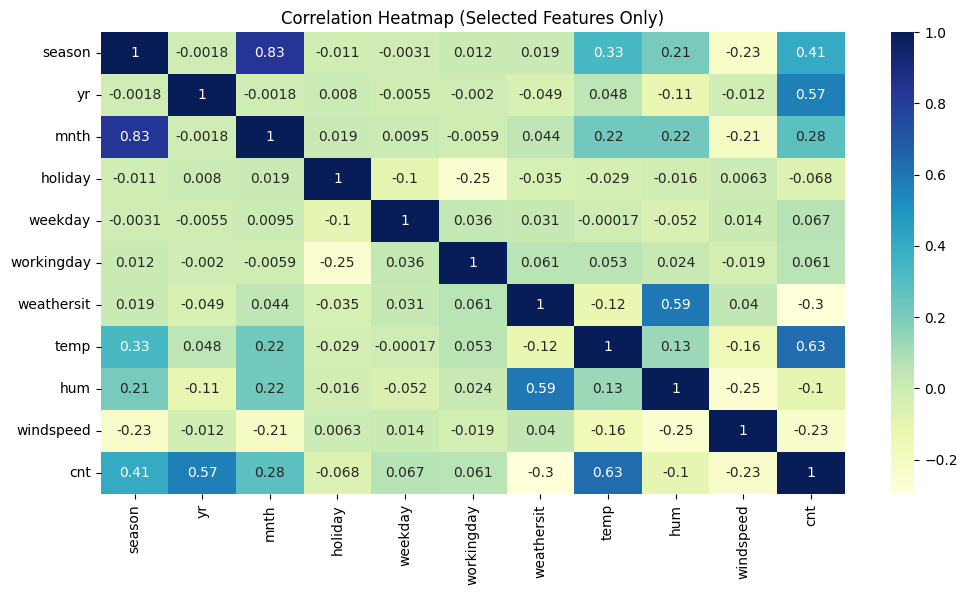

In [38]:
# Remove irrelevant or redundant columns before correlation
df_corr = df_day.drop(columns=["instant", "casual", "registered", "atemp"], errors="ignore")

corr = df_corr.corr(numeric_only=True)
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap (Selected Features Only)")
plt.show()



Before creating the correlation heatmap, I decided to remove a few columns that are not useful for analysis:

- **instant**: This is just an index number used to order the records. It does not carry any meaningful information about the data itself.  
- **casual** and **registered**: These two columns represent partial components of the target variable **cnt**. Since **cnt = casual + registered**, including them would create data leakage — the model would indirectly "see" the target during training.  
- **atemp**: This variable is almost identical to **temp**, as shown in the previous scatterplot. Keeping both would introduce redundancy, so I decided to use only **temp** in the analysis.

After removing these columns, the remaining features provide a clearer and more reliable view of the relationships affecting total bike rentals.

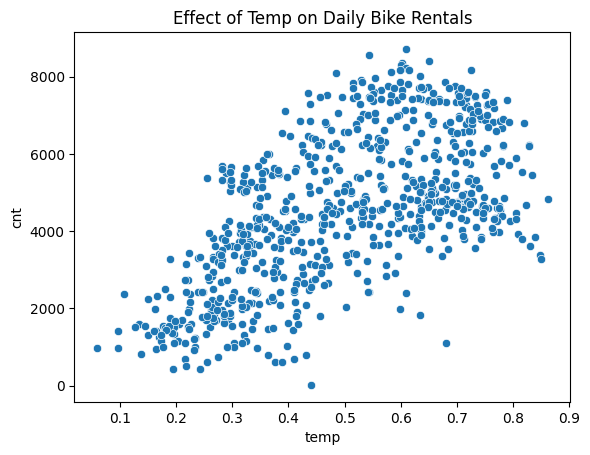

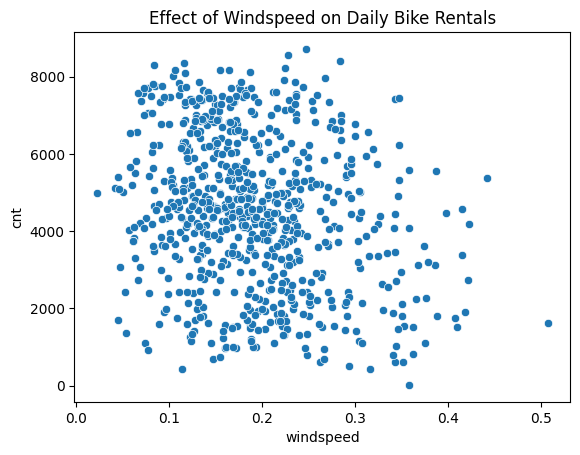

In [39]:
# Scatterplots for multiple features vs cnt
num_features = ["temp", "windspeed"]

for col in num_features:
    sns.scatterplot(data=df_corr, x=col, y="cnt")
    plt.title(f"Effect of {col.capitalize()} on Daily Bike Rentals")
    plt.show()


### Summary of Scatterplot Observations  

After analyzing the **Scatter Plot** for **temperature** against total daily rentals (**cnt**), it’s clear that temperature has the **strongest and most meaningful relationship** with rental counts.  
As temperature increases, the number of rentals rises noticeably — this trend is also confirmed by the **heatmap correlation**.  

However, when the **temperature becomes too high**, the number of rentals shows a **slight decrease**, suggesting that extremely hot weather may discourage people from biking.  

Other numerical feature **humidity**, show much weaker or less consistent patterns.  
Therefore, from a numerical perspective, **temperature** remains the most influential and logical feature affecting daily bike rental demand. 


## Exploring Categorical Features

After analyzing the numerical features, I now focus on the categorical ones to see how different categories affect the total number of daily rentals (**cnt**).  
I only include the features that show a meaningful relationship with **cnt**, which are **season**, **yr**, **mnth**, and **weathersit**.  
Features like **holiday**, **weekday**, and **workingday** have correlations close to zero and therefore are not analyzed further.


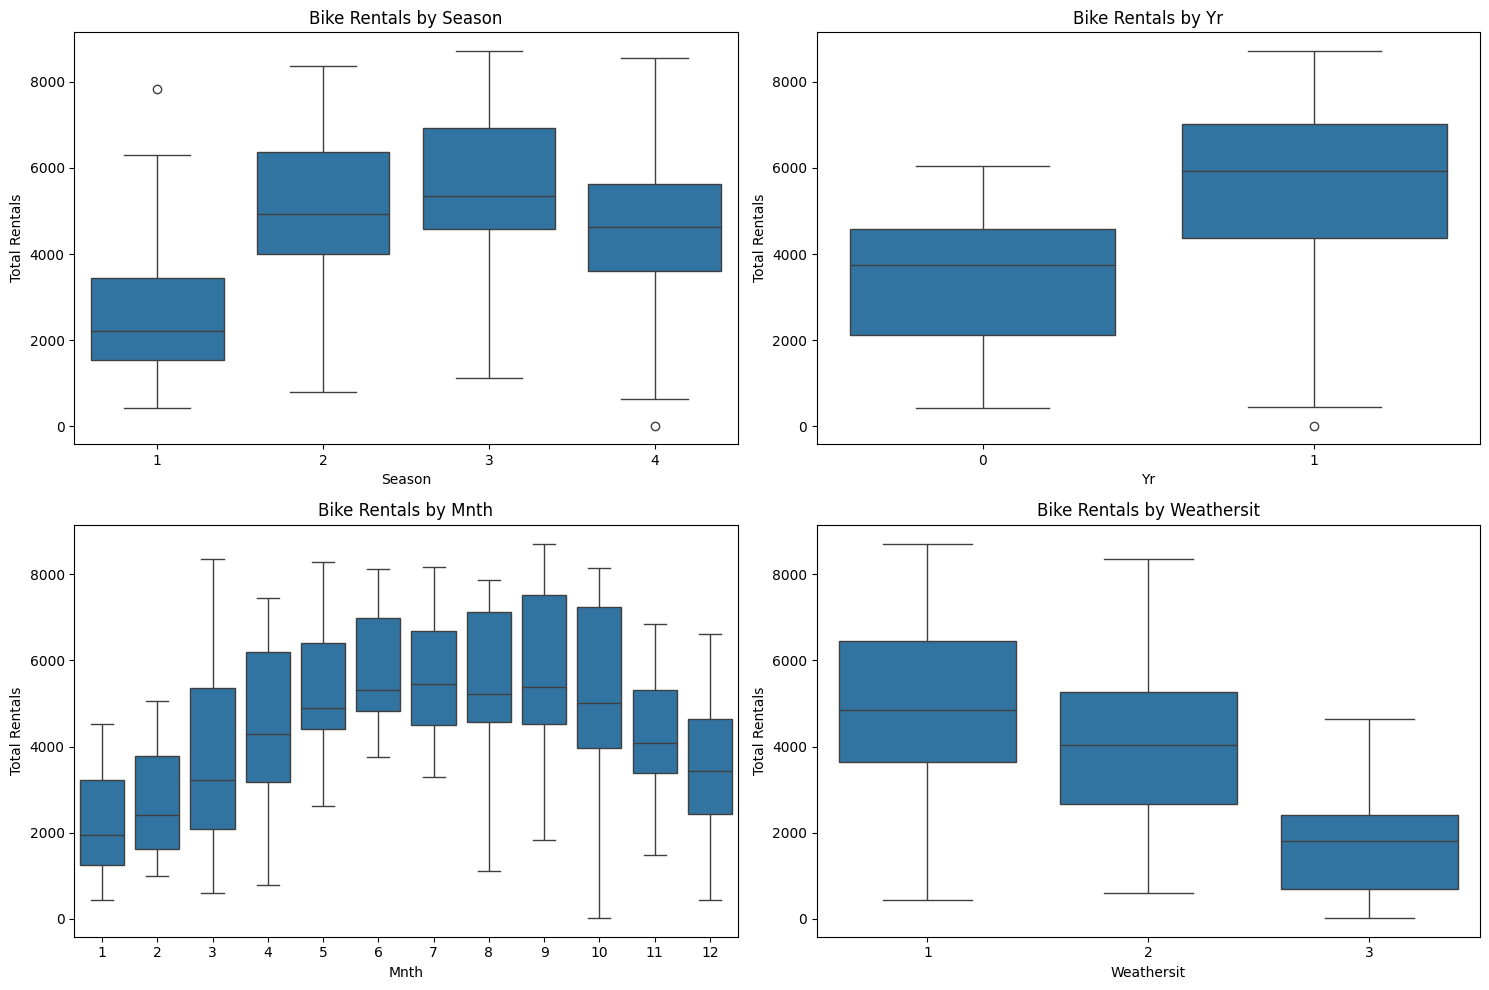

In [42]:
# Define categorical features to plot
cat_features = ["season", "yr", "mnth", "weathersit"]

# Set up subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, col in enumerate(cat_features):
    ax = axes[i // 2, i % 2]
    sns.boxplot(data=df_corr, x=col, y="cnt", ax=ax)
    ax.set_title(f"Bike Rentals by {col.capitalize()}")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Total Rentals")

plt.tight_layout()
plt.show()


From these boxplots, I can clearly see strong seasonal and weather-related patterns.  
Bike rentals are lowest during **Winter (1)** and reach their highest levels in **Summer (3)** and **Fall (4)**.  
In **2012**, total rentals are noticeably higher than in **2011**, showing that the bike-sharing program gained popularity over time.  
The **monthly trend** follows a similar pattern, increasing in warmer months and dropping during the colder period.  
Finally, the **weather situation** has a clear negative effect — clear days show the highest rentals, while rainy or snowy days lead to a sharp decline.

I did not include **holiday**, **weekday**, or **workingday** in the boxplots because their correlation with **cnt** was almost zero.  
This means they do not show meaningful variation in daily rental counts.  
In other words, the number of rentals remains quite similar on holidays and regular days, as well as across different weekdays or working days.  
Focusing only on features with stronger effects, such as **season**, **year**, **month**, and **weather situation**, helps create a clearer understanding of what truly influences daily bike rental demand.


## Closing — Data Understanding Summary

In this part of the analysis, I focused on understanding the structure and patterns within the dataset.  
The goal was to answer three main questions and identify which features most influence daily bike rentals.



### 1. Are there any missing or incorrect values?
I checked the dataset carefully and found **no missing or corrupted values**.  
All columns are complete, and their value ranges make sense.  
The data is already well-prepared and consistent, which means no major cleaning is needed before modeling.


### 2. Which features have the most impact on daily rentals?
From both the correlation analysis and visualizations, I realized that:
- **Temperature (temp)** has the **strongest positive effect** on daily rentals.  
- **Season** and **Year (yr)** also show clear patterns.
- **Weather situation (weathersit)** has a **negative relationship** with rentals.
- ** **Windspeed** shows **weaker negative effects**, but it still plays a small role in overall demand.



### 3. Are there any features that are redundant or unnecessary?
I observed that:
- **Atemp** is almost identical to **Temp**, so I will only keep **Temp**.  
- **Casual** and **Registered** are directly part of the target variable **cnt**, so I removed them to prevent data leakage.  
- **Instant** is only an index column and has no analytical meaning.  
- **Holiday**, **Weekday**, and **Workingday** show almost zero correlation with rentals, so they won’t add much predictive power.
- **Humidity** also has a very weak correlation (around 0.10), suggesting it contributes minimally to prediction, so I decided not to include it.



### Final Insights
Overall, I noticed that **weather and seasonal conditions** are the key drivers of bike rental demand.  
Clear, warm, and comfortable days attract far more users, while cold or rainy days significantly reduce activity.  
The dataset is clean, logical, and ready for further transformation and feature preparation.

In the next step, I will move to **Data Preparation**, where I will:
- Keep only the selected relevant features,  
- Encode categorical variables properly,  
- And prepare the dataset for model training.
